# Analisando Dados de Preços de Casas nos EUA
### FAESA Centro Universitário — Analise de dados
**Dataset:** [House Prices - Advanced Regression Techniques (Kaggle)](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)

---
##  Índice
1. [Configuração e Importações](#1-configuração-e-importações)
2. [Análise Exploratória de Dados (EDA)](#2-análise-exploratória-de-dados-eda)
3. [Feature Engineering](#3-feature-engineering)
4. [Aprendizagem Supervisionada — Regressão](#4-aprendizagem-supervisionada--regressão)
5. [Aprendizagem Supervisionada — Classificação](#5-aprendizagem-supervisionada--classificação)
6. [Aprendizagem Não Supervisionada](#6-aprendizagem-não-supervisionada)
7. [Métricas e Comparação dos Modelos](#7-métricas-e-comparação-dos-modelos)
8. [Conclusões](#8-conclusões)

In [1]:
# ── Instalação de dependências (caso necessário) ──────────────────────────────
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost mlxtend

# ── Bibliotecas gerais ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualização ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Pré-processamento ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Modelos supervisionados ───────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from xgboost import XGBRegressor, XGBClassifier

# ── Modelos não supervisionados ───────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── Configurações de estilo ───────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)
SEED = 42

print('✅ Todas as bibliotecas importadas com sucesso!')

✅ Todas as bibliotecas importadas com sucesso!


---
## 1. Configuração e Importações

In [2]:
# ── Carregamento dos dados ────────────────────────────────────────────────────
# Certifique-se de que train.csv e test.csv estão na mesma pasta do notebook
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print(f'Train: {train.shape[0]} linhas × {train.shape[1]} colunas')
print(f'Test:  {test.shape[0]} linhas × {test.shape[1]} colunas')
train.head()

Train: 1460 linhas × 81 colunas
Test:  1459 linhas × 80 colunas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



## 2. Análise Exploratória de Dados (EDA)

In [5]:
# ── Visão geral do dataset ────────────────────────────────────────────────────
print('=== INFORMAÇÕES GERAIS ===')
train.info()

=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-n

In [6]:
# ── Estatísticas descritivas ──────────────────────────────────────────────────
print('=== ESTATÍSTICAS DESCRITIVAS (variáveis numéricas) ===')
train.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

=== ESTATÍSTICAS DESCRITIVAS (variáveis numéricas) ===


,count,mean,std,min,25%,50%,75%,max
Id,1460.000000,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.000000,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.000000,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.000000,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.000000,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.000000,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.000000,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.000000,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.000000,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000


              Qtd Faltante  % Faltante
PoolQC                1453       99.52
MiscFeature           1406       96.30
Alley                 1369       93.77
Fence                 1179       80.75
MasVnrType             872       59.73
FireplaceQu            690       47.26
LotFrontage            259       17.74
GarageType              81        5.55
GarageYrBlt             81        5.55
GarageFinish            81        5.55
GarageQual              81        5.55
GarageCond              81        5.55
BsmtFinType2            38        2.60
BsmtExposure            38        2.60
BsmtFinType1            37        2.53
BsmtCond                37        2.53
BsmtQual                37        2.53
MasVnrArea               8        0.55
Electrical               1        0.07


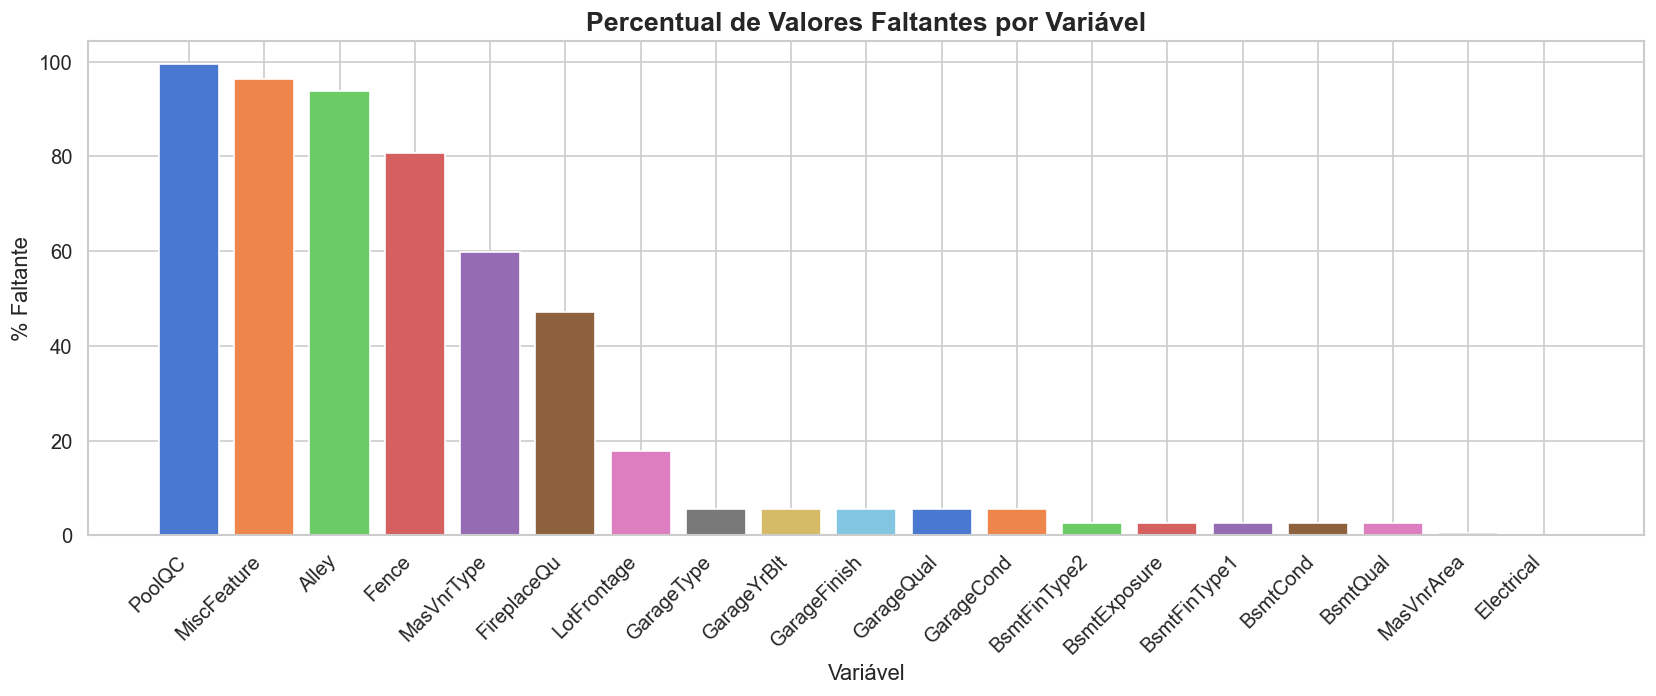

In [7]:
# ── Valores faltantes ─────────────────────────────────────────────────────────
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({'Qtd Faltante': missing, '% Faltante': missing_pct})
print(missing_df)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(missing_df.index, missing_df['% Faltante'], color=sns.color_palette('muted', len(missing_df)))
ax.set_title('Percentual de Valores Faltantes por Variável', fontsize=16, fontweight='bold')
ax.set_ylabel('% Faltante')
ax.set_xlabel('Variável')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

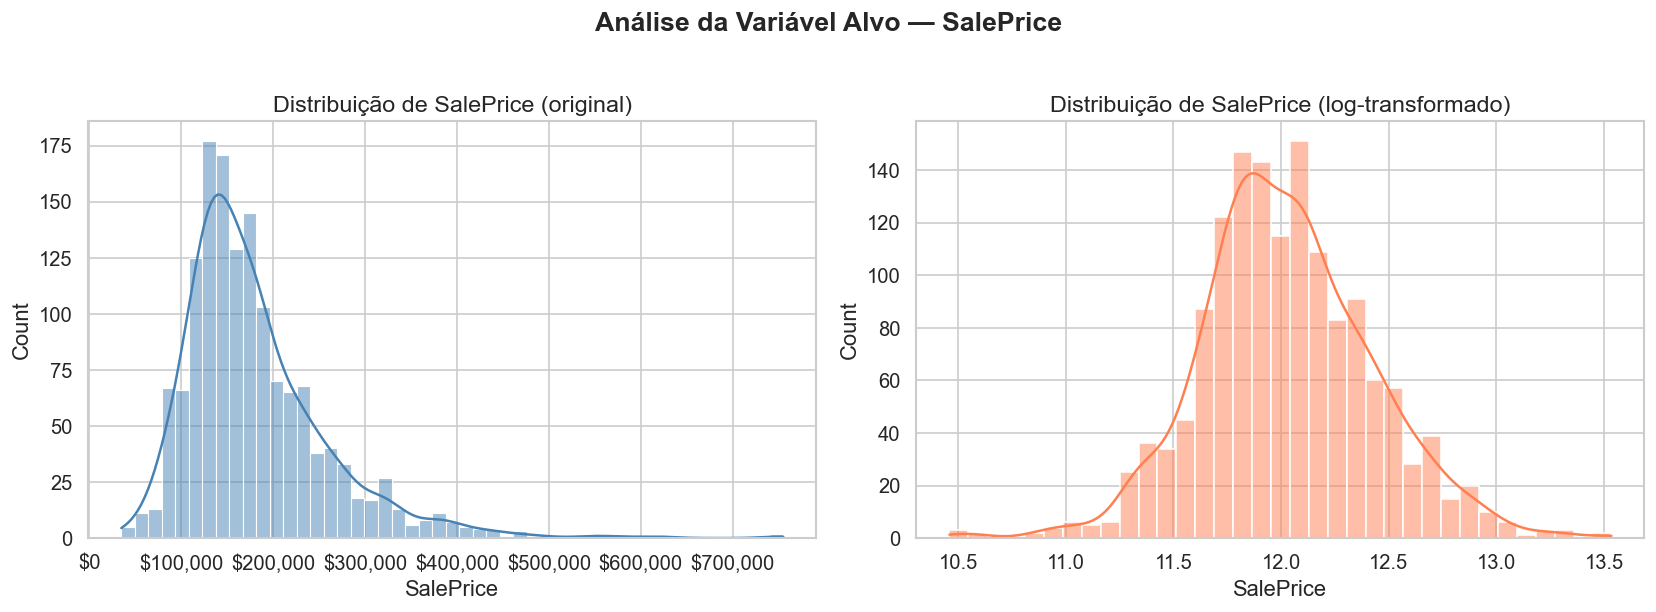

Skewness original:       1.883
Skewness log-transform:  0.121


In [8]:
# ── Distribuição da variável alvo: SalePrice ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição original
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição de SalePrice (original)', fontsize=14)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Distribuição log-transformada
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribuição de SalePrice (log-transformado)', fontsize=14)

plt.suptitle('Análise da Variável Alvo — SalePrice', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Skewness original:       {train["SalePrice"].skew():.3f}')
print(f'Skewness log-transform:  {np.log1p(train["SalePrice"]).skew():.3f}')

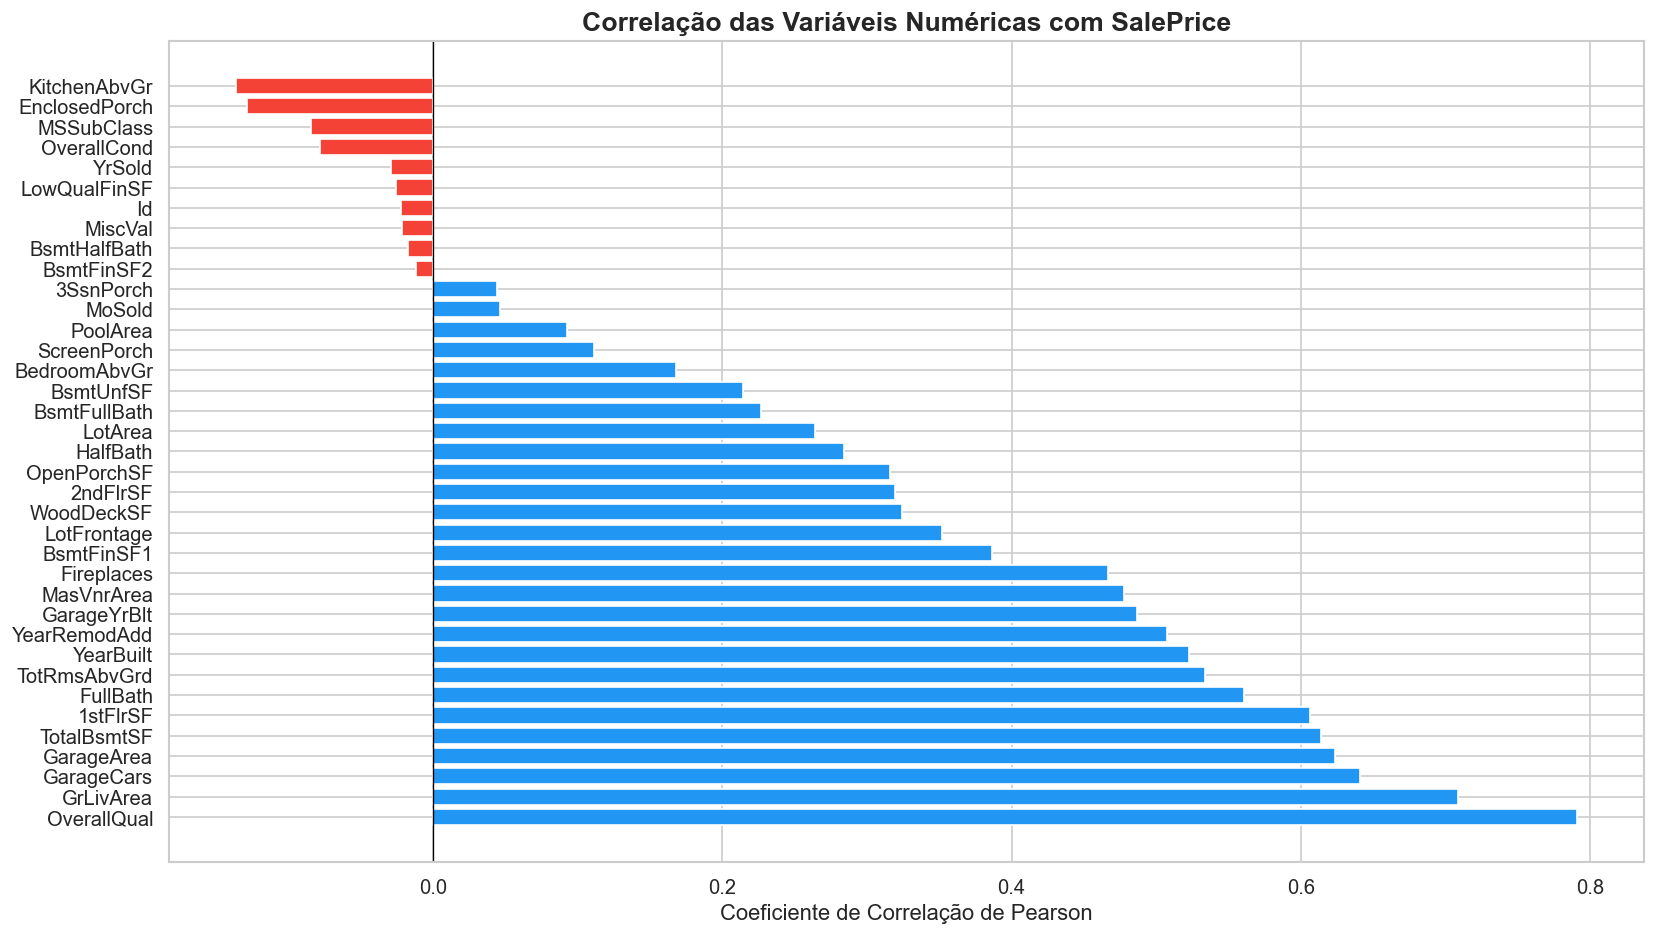

In [9]:
# ── Correlações com SalePrice ─────────────────────────────────────────────────
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#2196F3' if v > 0 else '#F44336' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação das Variáveis Numéricas com SalePrice', fontsize=16, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlação de Pearson')
plt.tight_layout()
plt.show()

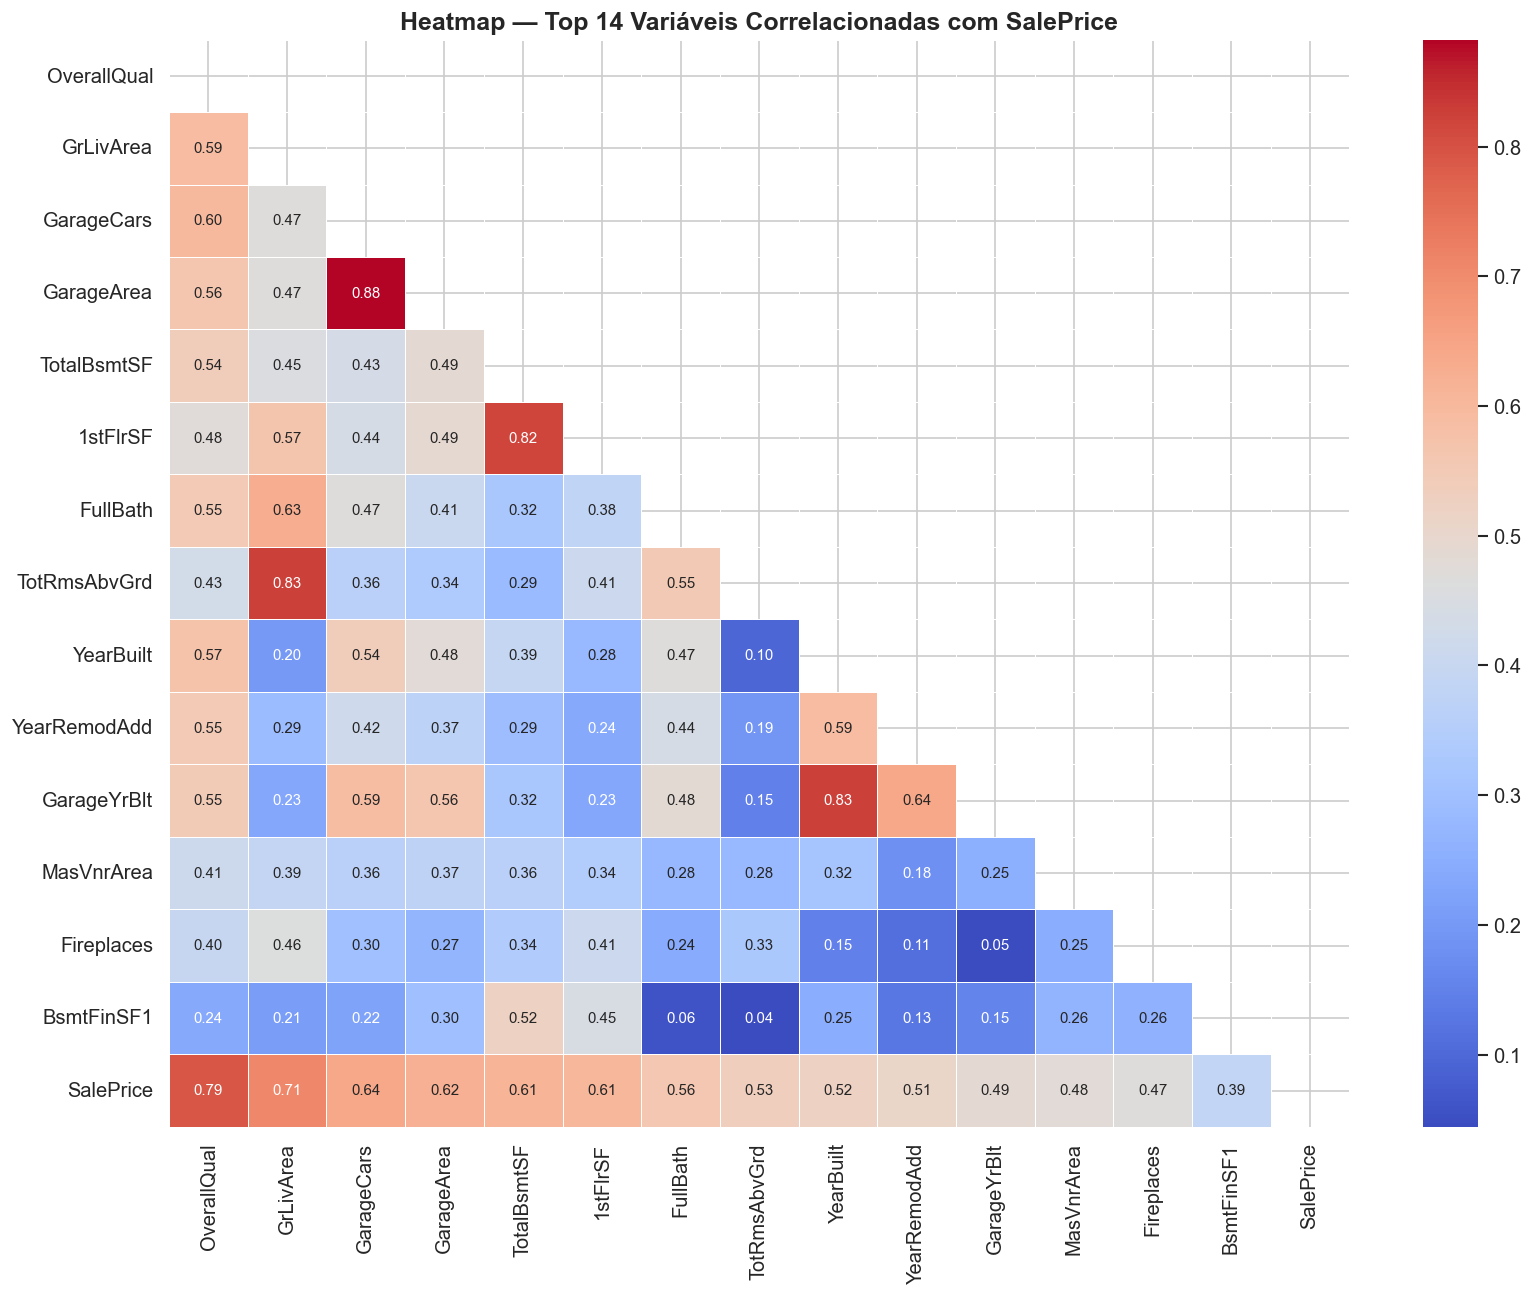

In [10]:
# ── Heatmap das top 15 correlações ───────────────────────────────────────────
top_features = corr.abs().nlargest(14).index.tolist() + ['SalePrice']

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(train[top_features].corr(), dtype=bool))
sns.heatmap(
    train[top_features].corr(),
    mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5,
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Heatmap — Top 14 Variáveis Correlacionadas com SalePrice', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

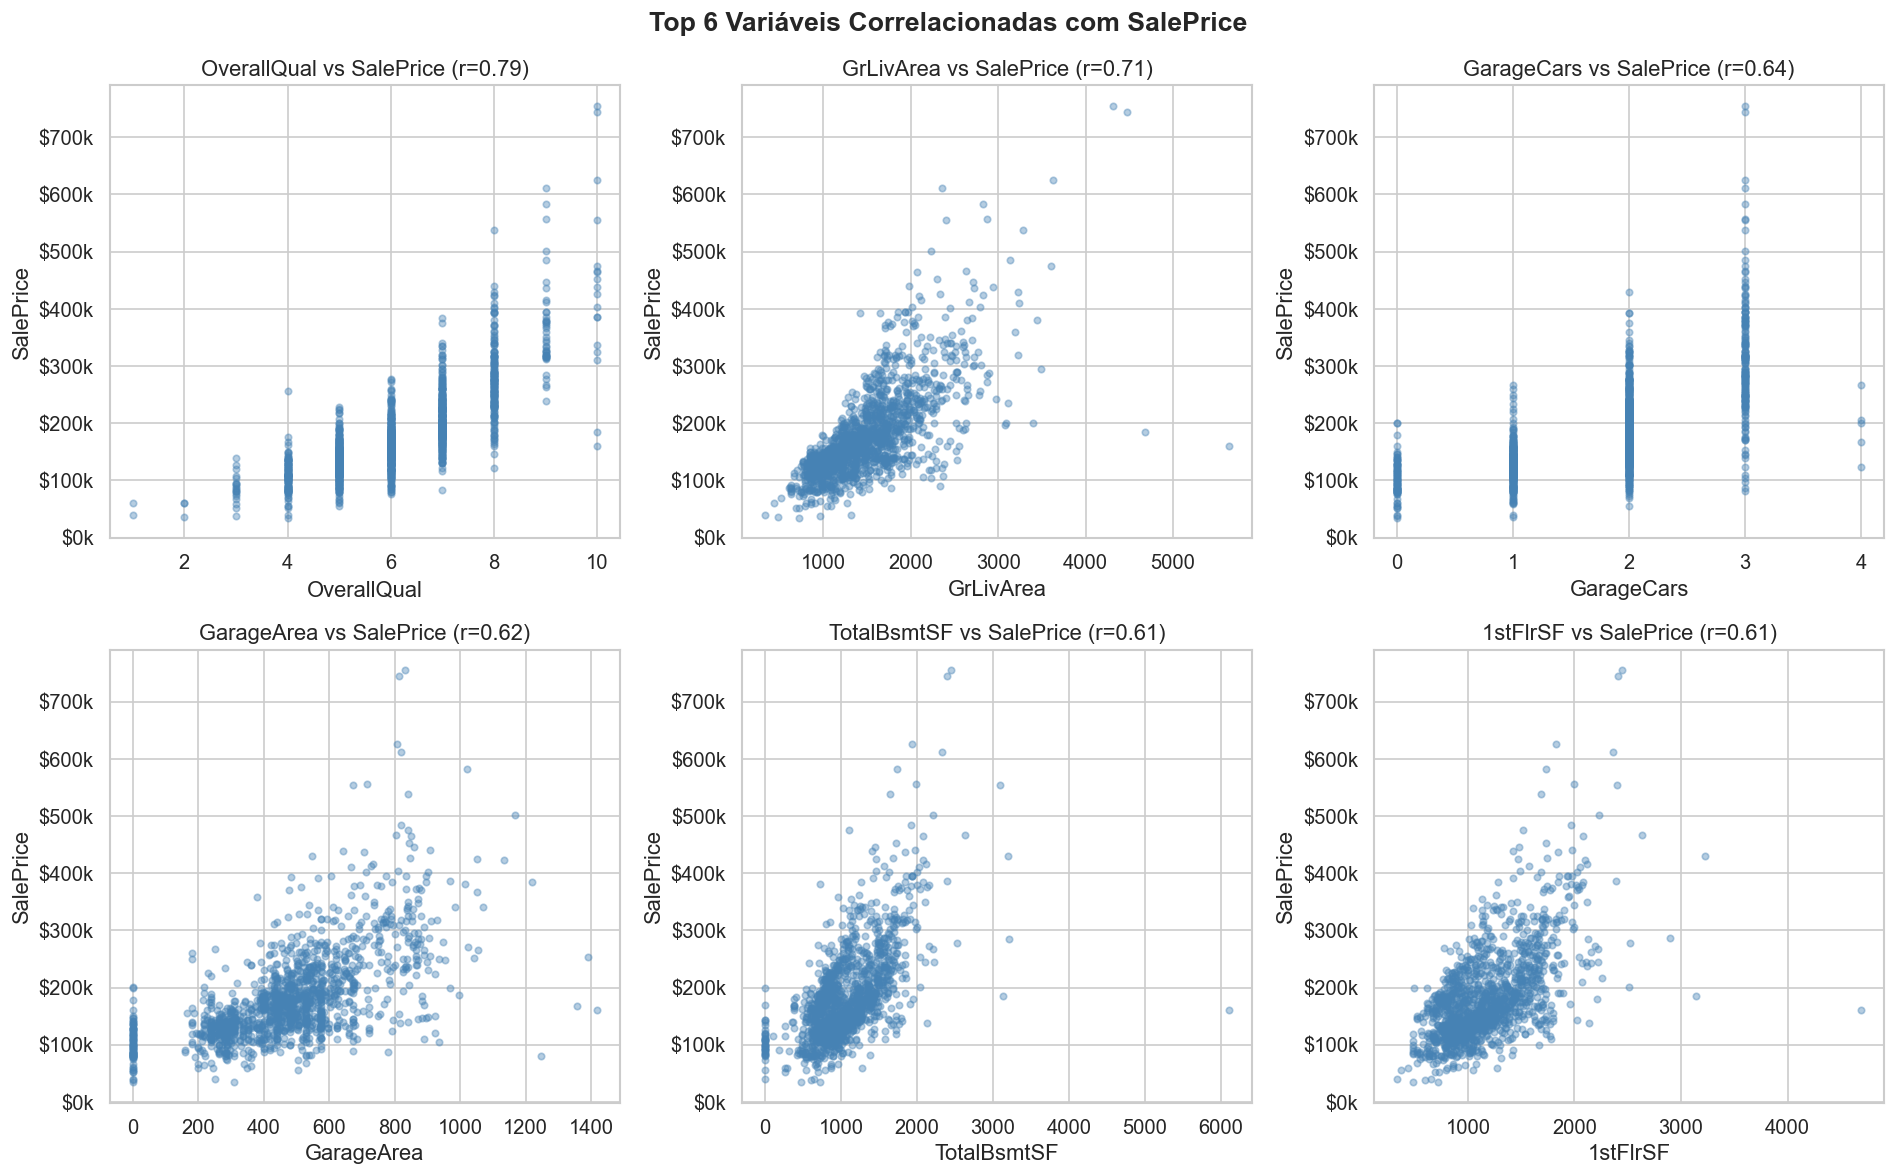

In [11]:
# ── Scatter plots: top correlações positivas ──────────────────────────────────
top_pos = corr.nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), top_pos):
    ax.scatter(train[col], train['SalePrice'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{col} vs SalePrice (r={train[col].corr(train["SalePrice"]):.2f})')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.suptitle('Top 6 Variáveis Correlacionadas com SalePrice', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

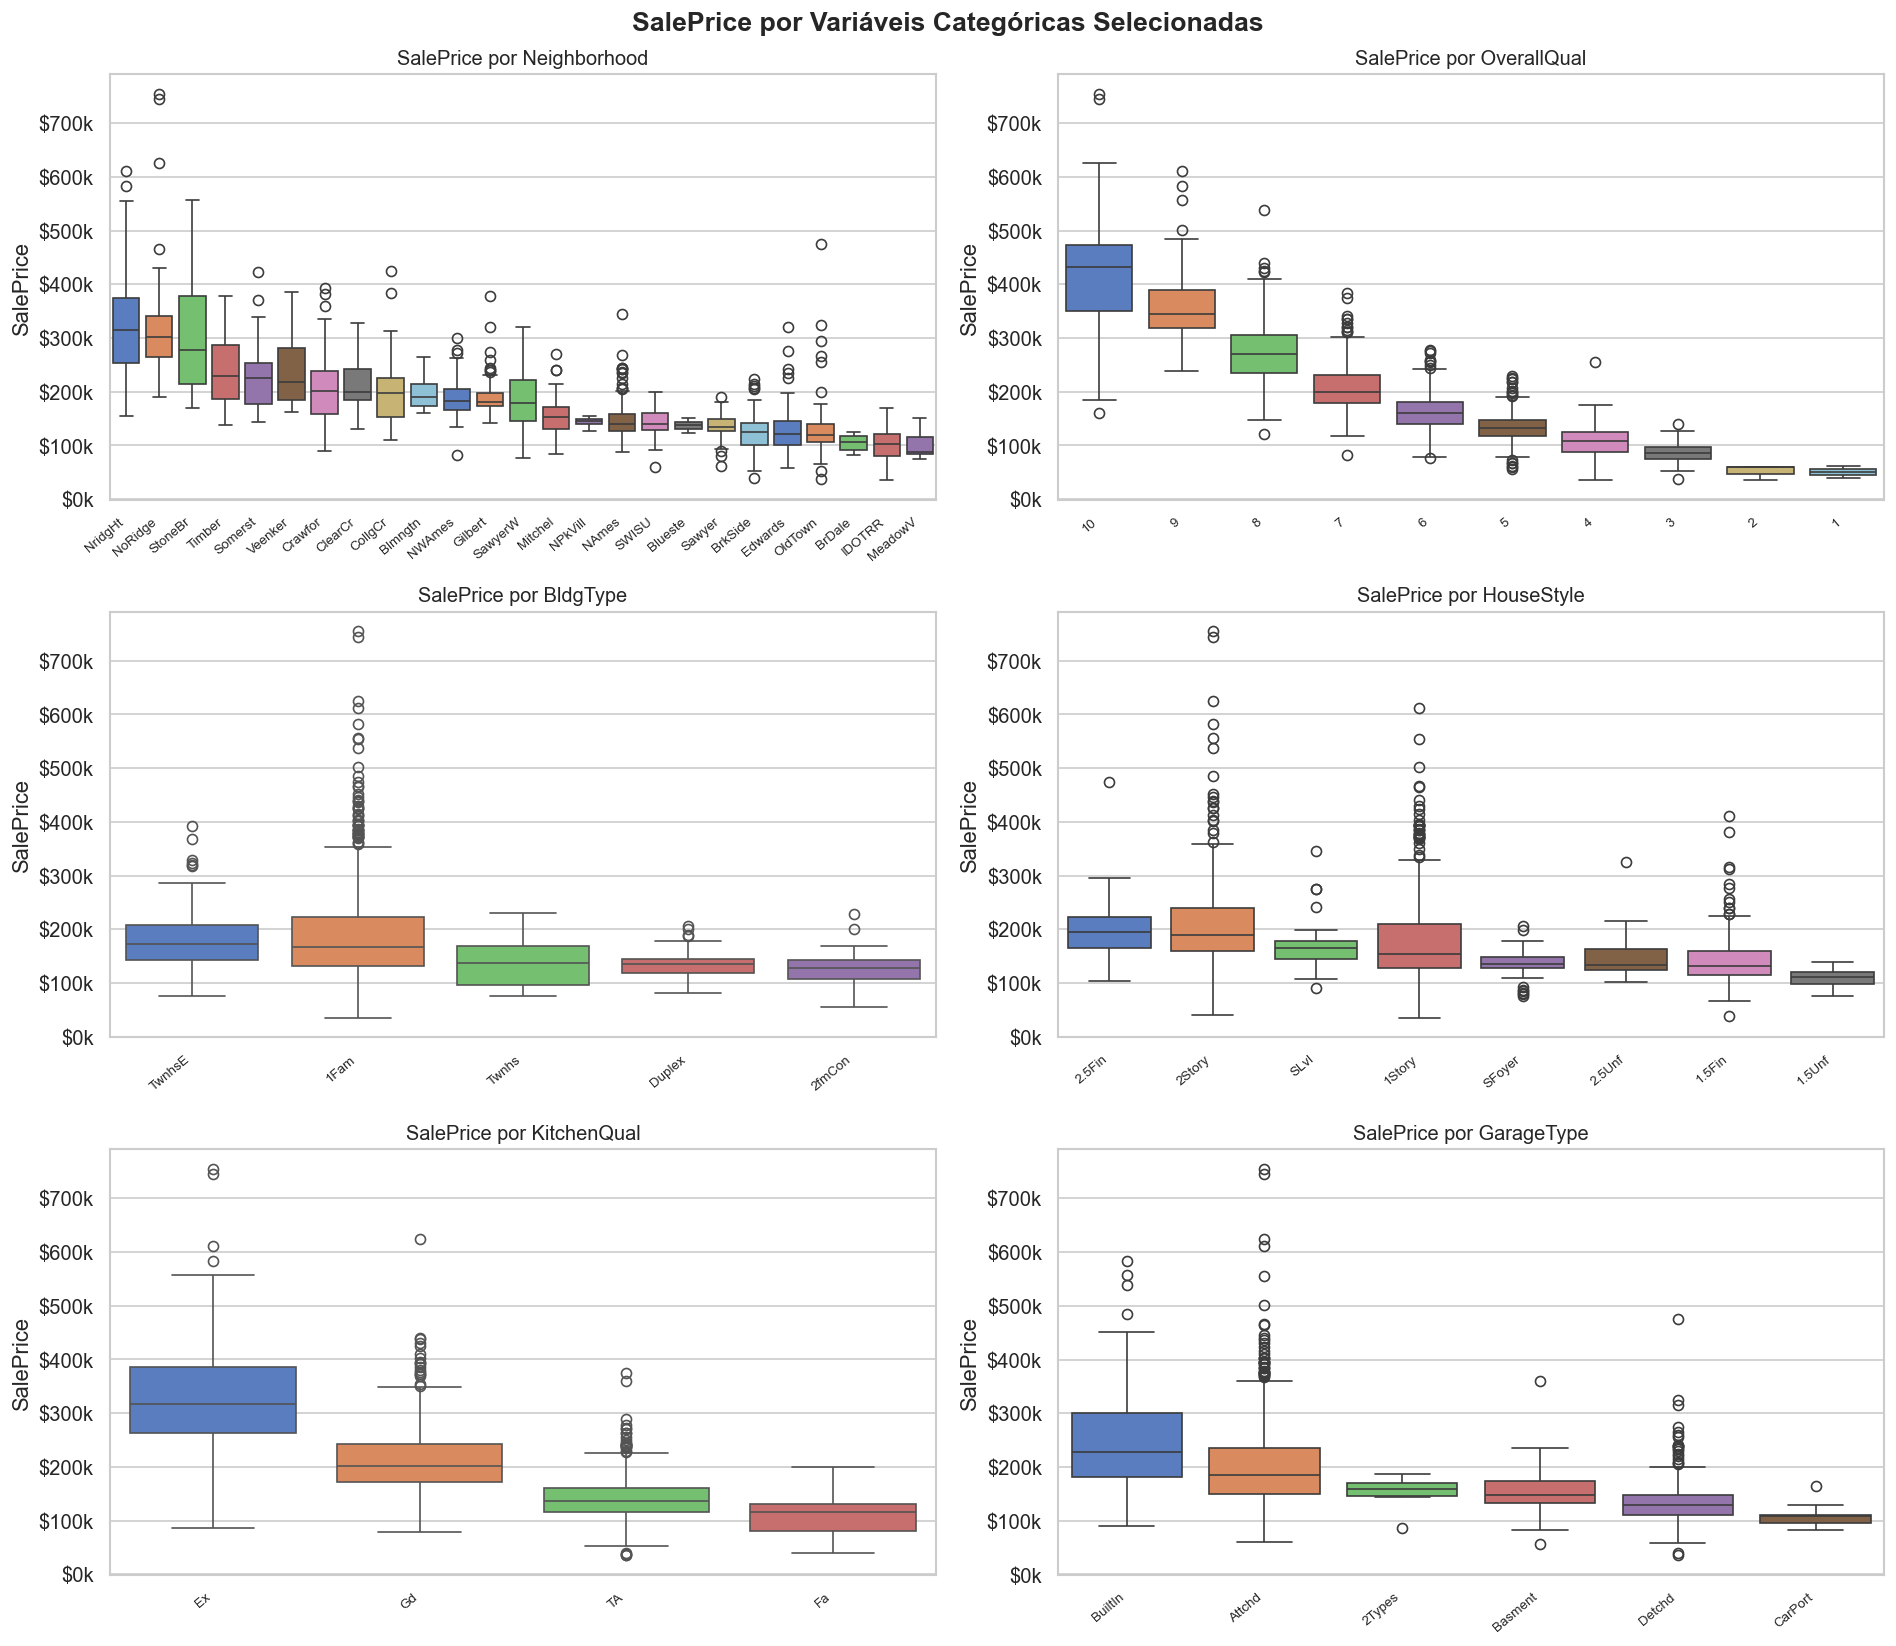

In [12]:
# ── Análise de variáveis categóricas ─────────────────────────────────────────
cat_cols = ['Neighborhood', 'OverallQual', 'BldgType', 'HouseStyle', 'KitchenQual', 'GarageType']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
for ax, col in zip(axes.flatten(), cat_cols):
    order = train.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='SalePrice', order=order, ax=ax, palette='muted')
    ax.set_title(f'SalePrice por {col}', fontsize=12)
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
plt.suptitle('SalePrice por Variáveis Categóricas Selecionadas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

In [13]:
# ── Cópia dos dados ───────────────────────────────────────────────────────────
df = train.copy()

# ── 1) Criação de novas features ──────────────────────────────────────────────
df['TotalSF']       = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath']     = (df['FullBath'] + 0.5 * df['HalfBath'] +
                       df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
df['HouseAge']      = df['YrSold'] - df['YearBuilt']
df['RemodAge']      = df['YrSold'] - df['YearRemodAdd']
df['IsRemodeled']   = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df['HasGarage']     = (df['GarageArea'] > 0).astype(int)
df['HasPool']       = (df['PoolArea'] > 0).astype(int)
df['HasFireplace']  = (df['Fireplaces'] > 0).astype(int)
df['HasBsmt']       = (df['TotalBsmtSF'] > 0).astype(int)
df['PorchTotalSF']  = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                       df['3SsnPorch'] + df['ScreenPorch'])

print('✅ Novas features criadas:')
new_feats = ['TotalSF','TotalBath','HouseAge','RemodAge','IsRemodeled',
             'HasGarage','HasPool','HasFireplace','HasBsmt','PorchTotalSF']
df[new_feats + ['SalePrice']].describe().T

✅ Novas features criadas:


,count,mean,std,min,25%,50%,75%,max
TotalSF,1460.0,2567.048630,821.714421,334.0,2009.5,2474.0,3004.0,11752.0
TotalBath,1460.0,2.210616,0.785399,1.0,2.0,2.0,2.5,6.0
HouseAge,1460.0,36.547945,30.250152,0.0,8.0,35.0,54.0,136.0
RemodAge,1460.0,22.950000,20.640653,-1.0,4.0,14.0,41.0,60.0
IsRemodeled,1460.0,0.476712,0.499629,0.0,0.0,0.0,1.0,1.0
HasGarage,1460.0,0.944521,0.228992,0.0,1.0,1.0,1.0,1.0
HasPool,1460.0,0.004795,0.069100,0.0,0.0,0.0,0.0,1.0
HasFireplace,1460.0,0.527397,0.499420,0.0,0.0,1.0,1.0,1.0
HasBsmt,1460.0,0.974658,0.157217,0.0,1.0,1.0,1.0,1.0
PorchTotalSF,1460.0,87.084932,105.190364,0.0,0.0,48.0,136.0,1027.0


In [14]:
# ── 2) Tratamento de valores faltantes ────────────────────────────────────────

# Variáveis categóricas: NaN significa 'ausência' (ex: sem porão, sem garagem)
none_cols = [
    'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
    'GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
    'MasVnrType','MSSubClass'
]
for c in none_cols:
    if c in df.columns:
        df[c].fillna('None', inplace=True)

# Variáveis numéricas com ausência estrutural (valor 0)
zero_cols = [
    'GarageYrBlt','GarageArea','GarageCars',
    'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
    'BsmtFullBath','BsmtHalfBath','MasVnrArea'
]
for c in zero_cols:
    if c in df.columns:
        df[c].fillna(0, inplace=True)

# Demais categóricas: moda
cat_remaining = df.select_dtypes(include='object').columns
for c in cat_remaining:
    df[c].fillna(df[c].mode()[0], inplace=True)

# Demais numéricas: mediana
num_remaining = df.select_dtypes(include=[np.number]).columns
for c in num_remaining:
    df[c].fillna(df[c].median(), inplace=True)

print(f'Valores faltantes restantes: {df.isnull().sum().sum()}')

Valores faltantes restantes: 0


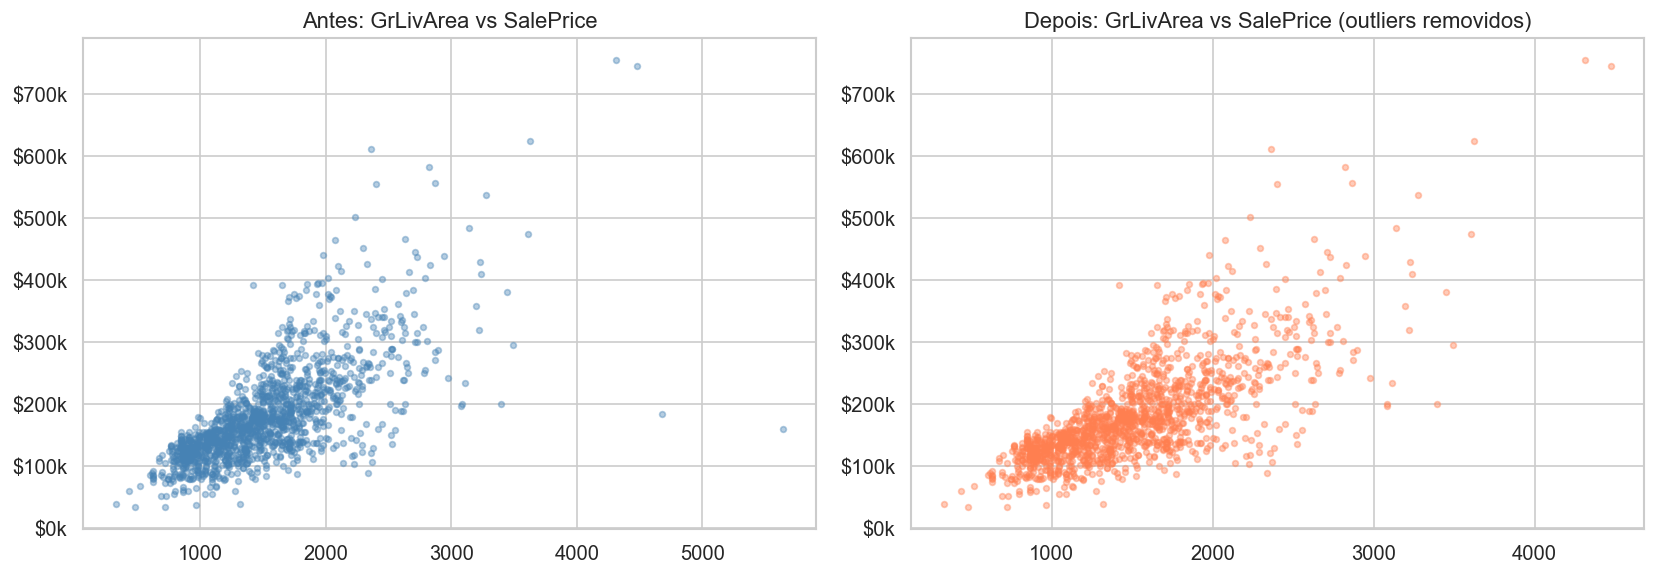

Dataset após remoção de outliers: (1458, 91)


In [15]:
# ── 3) Tratamento de Outliers (GrLivArea) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, s=12, color='steelblue')
axes[0].set_title('Antes: GrLivArea vs SalePrice')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Remover outliers óbvios
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))]

axes[1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, s=12, color='coral')
axes[1].set_title('Depois: GrLivArea vs SalePrice (outliers removidos)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()
print(f'Dataset após remoção de outliers: {df.shape}')

In [16]:
# ── 4) Log-transformação do target e de features assimétricas ─────────────────
df['SalePrice_log'] = np.log1p(df['SalePrice'])

# Corrigir skew de features numéricas
skew_cols = df[num_remaining].apply(lambda x: x.skew()).sort_values(ascending=False)
high_skew = skew_cols[skew_cols.abs() > 0.75].index.tolist()
# Remover colunas binárias e o target
skip = ['SalePrice','SalePrice_log','Id'] + [c for c in df.columns if df[c].nunique() <= 2]
high_skew = [c for c in high_skew if c not in skip]

for c in high_skew:
    if c in df.columns and (df[c] >= 0).all():
        df[c] = np.log1p(df[c])

print(f'Features com skew corrigido: {len(high_skew)}')

Features com skew corrigido: 23


In [17]:
# ── 5) Encoding de variáveis categóricas ──────────────────────────────────────
df_encoded = df.copy()

# Ordinal encoding para qualidade (Ex: Ex=5, Gd=4, TA=3, Fa=2, Po=1, None=0)
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
quality_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond',
                'HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond']
for c in quality_cols:
    if c in df_encoded.columns:
        df_encoded[c] = df_encoded[c].map(quality_map).fillna(0).astype(int)

# One-Hot Encoding para demais categóricas
cat_cols_enc = df_encoded.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols_enc, drop_first=True)

print(f'Shape após encoding: {df_encoded.shape}')
print(f'Tipos: {df_encoded.dtypes.value_counts().to_dict()}')

Shape após encoding: (1458, 243)
Tipos: {dtype('bool'): 185, dtype('int64'): 33, dtype('float64'): 25}


In [18]:
# ── 6) Preparar X e y ─────────────────────────────────────────────────────────
drop_cols = ['Id','SalePrice','SalePrice_log']
drop_cols = [c for c in drop_cols if c in df_encoded.columns]

X = df_encoded.drop(columns=drop_cols)
y_reg = df_encoded['SalePrice_log']        # Para regressão (log-transformado)
y_raw = df_encoded['SalePrice']            # Para visualizações
y_cls = (df_encoded['SalePrice'] >= df_encoded['SalePrice'].median()).astype(int)  # Para classificação

# Garantir que todas as colunas sejam numéricas
X = X.select_dtypes(include=[np.number])

# Normalização
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split treino/teste
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=SEED)
_, _, y_train_cls, y_test_cls = train_test_split(X_scaled, y_cls, test_size=0.2, random_state=SEED)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Classes (0=baixo, 1=alto): {y_cls.value_counts().to_dict()}')

X_train: (1166, 55) | X_test: (292, 55)
Classes (0=baixo, 1=alto): {1: 731, 0: 727}
